In [1]:
import pandas as pd
import feature_engineering_helper as hf
import pickle


In [2]:

### change this to 1 for quick test, 0 for full run
quick_test = 0
### change this to 1 for quick test, 0 for full run


if quick_test == 1:
    n_features_to_select=40
    step=50
    print("Quick test mode")
else:
    n_features_to_select=1
    step=5
    print("Full run mode")



Full run mode


In [3]:
data_prefix = '../0_data/processed_data/'
figure_prefix = '../Figures/'
non_feature_cols = ['SMILES', 'MP', 'Type', 'Ro5']
model_lists = ['RF', 'LGB', 'XGB']


if quick_test == 1:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet').head(500)
else:
    df_all_feature = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')

df_all_feature

,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5,SMILES,Type
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0.346320,1,ON=Cc1cscc1,Train
1,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.742933,1,O=C1CC[C@]2(C(=C1)CC[C@@H]1[C@@H]2[C@H](O)C[C@...,Train
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0.336491,1,[O-][n+]1ccccc1,Train
3,0,0,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0.470129,1,OC1CCC2(C(C1)CC=C1C2CCC2(C1CCC2C(CCC(C(C)C)C)C...,Train
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.635067,1,CC(=O)c1ccc(cc1)Br,Train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17215,0,0,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0.261785,1,c1ccc2c(c1)c1cc3ccc4c(c3nc1cc2)cccc4,Test
17216,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0.730914,1,COc1cc(OC)cc(c1C#N)OC,Test
17217,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,7,0,0.596953,1,OCCCCCCCCCCc1ccccc1,Test
17218,0,0,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0.439796,1,Clc1c2OC3Cc4c(C3Oc2c(c(c1Cl)Cl)Cl)cccc4,Test


In [4]:
data_with_features_train = df_all_feature[df_all_feature['Type'] == 'Train']
print(data_with_features_train.shape)

data_with_features_train.describe()

(12054, 388)


,MACCS_0,MACCS_1,MACCS_10,MACCS_100,MACCS_101,MACCS_102,MACCS_103,MACCS_104,MACCS_105,MACCS_106,...,RDKit_fr_sulfone,RDKit_fr_term_acetylene,RDKit_fr_tetrazole,RDKit_fr_thiazole,RDKit_fr_thiocyan,RDKit_fr_thiophene,RDKit_fr_unbrch_alkane,RDKit_fr_urea,RDKit_qed,Ro5
count,12054.0,12054.0,12054.0,12054.00000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,...,12054.000000,12054.000000,12054.00000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000,12054.000000
mean,0.0,0.0,0.0,0.12220,0.276755,0.189398,0.163016,0.156131,0.289945,0.187573,...,0.011283,0.005807,0.00307,0.016592,0.000913,0.017339,0.391322,0.022648,0.586909,0.978679
std,0.0,0.0,0.0,0.32753,0.447413,0.391840,0.369396,0.362994,0.453756,0.390387,...,0.108719,0.084270,0.05532,0.129676,0.037545,0.139149,2.300519,0.152094,0.164722,0.144457
min,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.034615,0.000000
25%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.485905,1.000000
50%,0.0,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.600263,1.000000
75%,0.0,0.0,0.0,0.00000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.705439,1.000000
max,0.0,0.0,0.0,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2.000000,4.000000,1.00000,2.000000,2.000000,3.000000,41.000000,2.000000,0.945893,1.000000


In [5]:
def feature_engineering_workflow(model_type, df):

    data = df.copy()
    tolerance = 0.01

    # Extract all feature columns
    all_feature_cols = data.drop(columns=non_feature_cols, axis=1).columns.tolist()
    print(f"Total number of features: {len(all_feature_cols)}")
    print()

    # Reduce features by variance threshold
    variance_threshold = 0.01
    print(f'Variance threshold feature selection: variance_threshold={variance_threshold}')
    df_X_variance = hf.reduce_features_by_variance(data[all_feature_cols], variance_threshold=variance_threshold)
    print()


    print(f'RFE feature selection: model={model_type}, tolerance={tolerance}, n_features_to_select={n_features_to_select}, step={step}')
    # Reduce features by RFE
    RFE_results = hf.reduce_features_by_RFE(df_X_variance, data['MP'], model = model_type, tolerance = tolerance, n_features_to_select=n_features_to_select, step=step, metric='rmse', cv_strategy=None)
    print()

    # Plot RFE results
    hf.RFE_plot(RFE_results, tolerance , model_type,save_path = figure_prefix + f'RFE_plot_{model_type}.png')


    df_X_RFE = df_X_variance[RFE_results['best_features']]


    return df_X_variance, RFE_results, df_X_RFE

Running feature engineering workflow with RF model
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 51
Remaining features: 333

RFE feature selection: model=RF, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 328 | RMSE: 38.3545 ± 1.2160 | Removed: [MACCS_31, MACCS_32, MACCS_58, RDKit_EState_VSA11, RDKit_fr_N_O]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 278 | RMSE: 38.3502 ± 1.2428 | Removed: [MACCS_81, MACCS_84, MACCS_86, MACCS_88, RDKit_fr_sulfide]


...

Iteration 50/67 | Features: 78 | RMSE: 38.6695 ± 1.2667 | Removed: [RDKit_Chi3n, RDKit_SlogP_VSA3, RDKit_SlogP_VSA5, RDKit_fr_NH0, RDKit_fr_NH1]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 28 | RMSE: 39.0263 ± 1.1494 | Removed: [RDKit_BalabanJ, RDKit_HallKierAlpha, RDKit_Phi, RDKit_SlogP_VSA2, RDKit_VSA_EState6]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 38.3250
Threshold (1.0% tolerance): 38.7082

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 63
  Selected RMSE: 38.6646
  Best features (Top 5): ['RDKit_TPSA', 'RDKit_BertzCT', 'RDKit_NumHDonors', 'RDKit_RingCount', 'RDKit_NHOHCount']



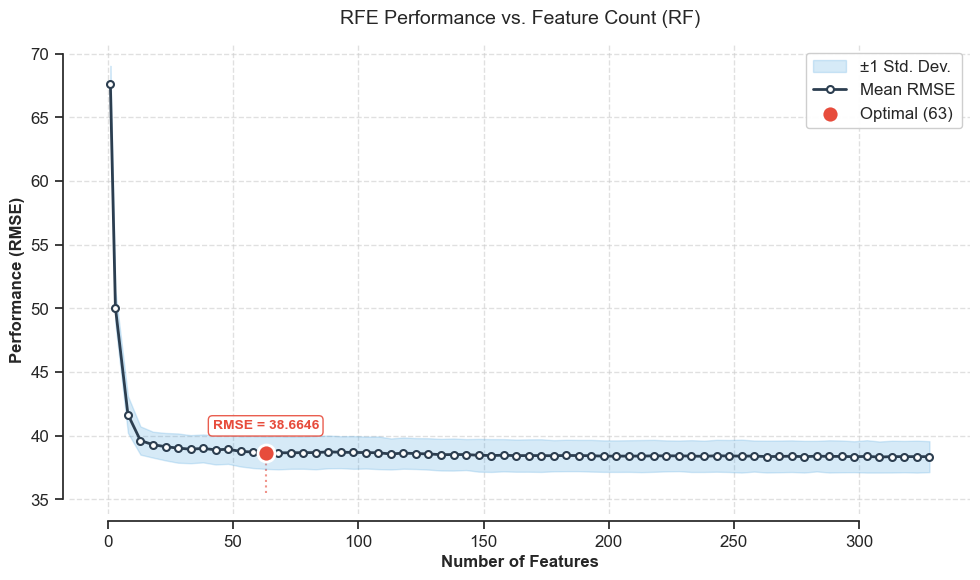

  Optimal Feature Set: 63 features
  Best RMSE: 38.6646

Running feature engineering workflow with LGB model
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 51
Remaining features: 333

RFE feature selection: model=LGB, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   0%|          | 0/67 iteration

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010815 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24777
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 333
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010965 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24761
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 328
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.041545 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24659
[LightGBM] [Info] Number of data points in the train set: 10848, number of used features: 328
[LightGBM] [Info]

RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 328 | RMSE: 37.1218 ± 1.3601 | Removed: [MACCS_158, MACCS_159, MACCS_164, MACCS_54, RDKit_fr_benzene]
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24761
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 328
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 24735
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 323
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.022520 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info]

...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000257 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 8
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000179 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 3
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 10848, number of used features: 3
[LightGBM] [Info] Start trai

RFE Feature Selection:  99%|█████████▊| 66/67 iteration

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000196 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 3
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000135 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 1
[LightGBM] [Info] Start training from score 126.431143
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 255
[LightGBM] [Info] Number of data points in the train set: 10848, number of used features: 1
[LightGBM] [Info] Start train

RFE Feature Selection: 100%|██████████| 67/67 iteration


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003477 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19224
[LightGBM] [Info] Number of data points in the train set: 12054, number of used features: 108
[LightGBM] [Info] Start training from score 126.431143

Global best RMSE: 37.0231
Threshold (1.0% tolerance): 37.3933

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 108
  Selected RMSE: 37.2005
  Best features (Top 5): ['RDKit_TPSA', 'RDKit_FpDensityMorgan3', 'RDKit_NumRotatableBonds', 'RDKit_VSA_EState4', 'RDKit_BertzCT']



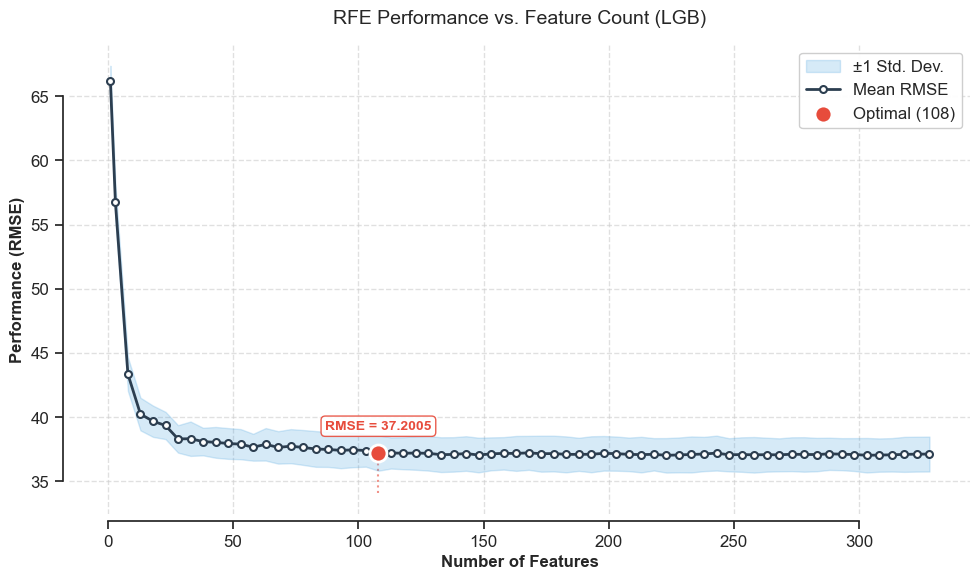

  Optimal Feature Set: 108 features
  Best RMSE: 37.2005

Running feature engineering workflow with XGB model
Total number of features: 384

Variance threshold feature selection: variance_threshold=0.01
Original features: 384
Removed features: 51
Remaining features: 333

RFE feature selection: model=XGB, tolerance=0.01, n_features_to_select=1, step=5


RFE Feature Selection:   1%|▏         | 1/67 iteration

Iteration 0/67 | Features: 328 | RMSE: 37.8286 ± 1.1163 | Removed: [MACCS_162, MACCS_28, RDKit_fr_amide, RDKit_fr_azo, RDKit_fr_benzene]


RFE Feature Selection:  16%|█▋        | 11/67 iteration

Iteration 10/67 | Features: 278 | RMSE: 38.1257 ± 1.1212 | Removed: [MACCS_117, MACCS_125, MACCS_134, MACCS_27, RDKit_fr_Al_COO]


...

Iteration 50/67 | Features: 78 | RMSE: 37.9971 ± 1.1909 | Removed: [MACCS_89, RDKit_FpDensityMorgan1, RDKit_Kappa2, RDKit_fr_ArN, RDKit_qed]


RFE Feature Selection:  91%|█████████ | 61/67 iteration

Iteration 60/67 | Features: 28 | RMSE: 40.6774 ± 1.2034 | Removed: [MACCS_142, RDKit_NumAromaticCarbocycles, RDKit_NumAtomStereoCenters, RDKit_SlogP_VSA1, RDKit_SlogP_VSA2]


RFE Feature Selection: 100%|██████████| 67/67 iteration



Global best RMSE: 37.6052
Threshold (1.0% tolerance): 37.9812

✓ RFE Feature Selection Complete (Parsimonious)
  Selected number of features: 53
  Selected RMSE: 37.8752
  Best features (Top 5): ['RDKit_NumHDonors', 'RDKit_RingCount', 'RDKit_TPSA', 'RDKit_fr_Ar_COO', 'MACCS_165']



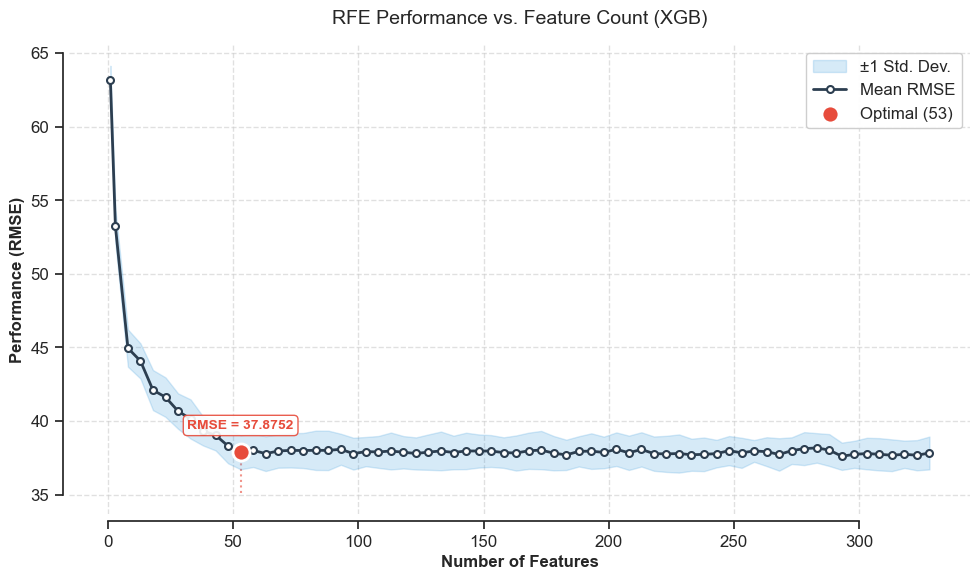

  Optimal Feature Set: 53 features
  Best RMSE: 37.8752



In [6]:
feature_engineering_dict = {}

for model_type in model_lists:
    print(f"Running feature engineering workflow with {model_type} model")
    df_X_variance, RFE_results, df_X_RFE = feature_engineering_workflow(model_type, data_with_features_train)
    feature_engineering_dict[(model_type)] = RFE_results
    print()

# pickle save the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'wb') as f:
    pickle.dump(feature_engineering_dict, f)

# Get the dataset

In [7]:
data_with_features = pd.read_parquet(data_prefix + 'data_with_all_features.parquet')
data_with_features_scaled = pd.read_parquet(data_prefix + 'data_with_all_features_scaled.parquet')

In [8]:
# load the feature_engineering_dict
with open('feature_engineering_dict.pkl', 'rb') as f:
    feature_engineering_dict = pickle.load(f)

In [9]:

for model_type in model_lists:
    best_features = feature_engineering_dict[(model_type)]['best_features']
    print(f"Best features for {model_type} model ({len(best_features)} features):")
    print(best_features)
    print()

    data_selected_features = data_with_features[non_feature_cols + best_features]
    data_selected_features_scaled = data_with_features_scaled[non_feature_cols + best_features]

    data_selected_features.to_parquet(data_prefix + f'data_with_selected_features_{model_type}.parquet')
    data_selected_features_scaled.to_parquet(data_prefix + f'data_with_selected_features_{model_type}_scaled.parquet')



Best features for RF model (63 features):
['RDKit_TPSA', 'RDKit_BertzCT', 'RDKit_NumHDonors', 'RDKit_RingCount', 'RDKit_NHOHCount', 'RDKit_FractionCSP3', 'RDKit_NumRotatableBonds', 'RDKit_BCUT2D_MRHI', 'MACCS_155', 'RDKit_SMR_VSA10', 'RDKit_VSA_EState2', 'RDKit_Kappa3', 'RDKit_BCUT2D_MRLOW', 'RDKit_VSA_EState3', 'RDKit_PEOE_VSA7', 'RDKit_VSA_EState4', 'RDKit_MolLogP', 'RDKit_FpDensityMorgan3', 'RDKit_SPS', 'RDKit_HallKierAlpha', 'RDKit_qed', 'RDKit_BCUT2D_MWHI', 'RDKit_VSA_EState1', 'RDKit_MinPartialCharge', 'RDKit_BCUT2D_LOGPHI', 'RDKit_AvgIpc', 'RDKit_MaxPartialCharge', 'RDKit_BCUT2D_LOGPLOW', 'RDKit_BCUT2D_MWLOW', 'RDKit_BalabanJ', 'RDKit_MinAbsPartialCharge', 'RDKit_Phi', 'RDKit_MaxAbsEStateIndex', 'RDKit_SlogP_VSA2', 'RDKit_VSA_EState6', 'RDKit_MaxAbsPartialCharge', 'RDKit_MinAbsEStateIndex', 'RDKit_BCUT2D_CHGLO', 'RDKit_FpDensityMorgan1', 'RDKit_PEOE_VSA8', 'RDKit_MinEStateIndex', 'RDKit_FpDensityMorgan2', 'RDKit_VSA_EState5', 'RDKit_PEOE_VSA9', 'RDKit_BCUT2D_CHGHI', 'RDKit_NumHe